Training Logistic Regression...
LogReg Best C: 1, Threshold: 0.0000
Training Random Forest...
RF Best Params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 500}, Threshold: 0.0366
Training XGBoost...


C:\Users\vipul\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [19:01:28] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGB Best Params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 500}, Threshold: 0.0067
Training Neural Network...


C:\Users\vipul\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
NN Training Finished. Threshold: 0.0000

FINE-TUNED RESULTS (Recall-Focused on Test Set)
| Model               |   Accuracy |   Precision |   Recall |     F1 |    AUC |   Threshold |
|:--------------------|-----------:|------------:|---------:|-------:|-------:|------------:|
| Logistic Regression |     0.0391 |      0.0325 |   1.0000 | 0.0629 | 0.8908 |      0.0000 |
| Random Forest       |     0.7703 |      0.1231 |   1.0000 | 0.2193 | 0.9458 |      0.0366 |
| Neural Network      |     0.0323 |      0.0304 |   0.9394 | 0.0589 | 0.8500 |      0.0000 |
| XGBoost             |     0.8759 |      0.1948 |   0.9091 | 0.3209 | 0.9382 |      0.0067 |

Plotting Confusion Matrices...


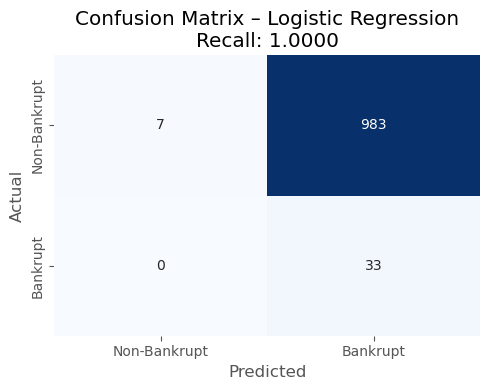

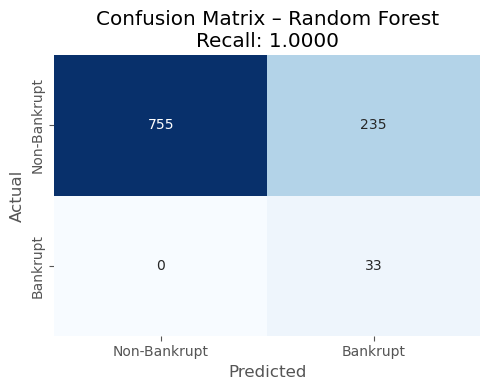

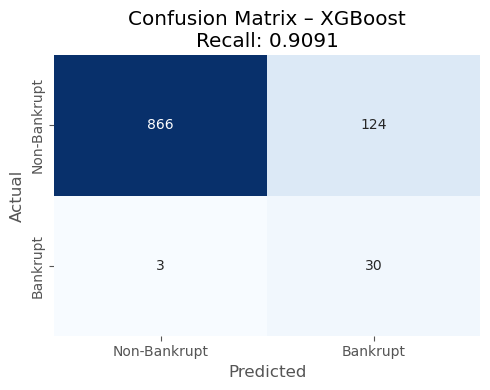

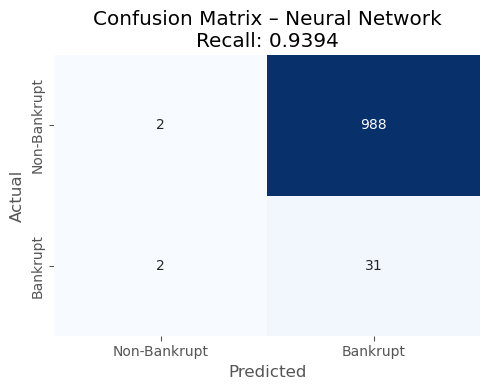


Plotting ROC Curves...


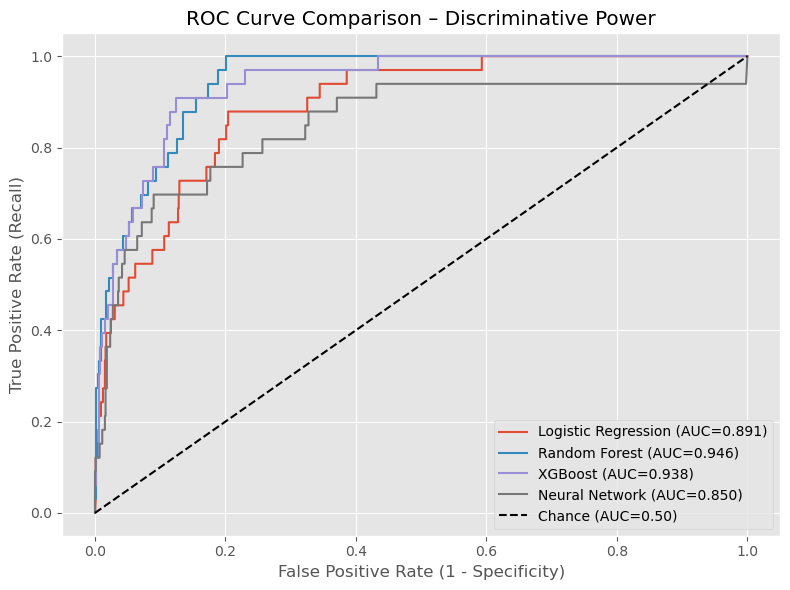

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, roc_curve, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

df = pd.read_csv("data.csv")
df.columns = df.columns.str.strip()

target = "Bankrupt?"
df = df.drop(columns=df.nunique()[df.nunique() <= 1].index).dropna()

X = df.drop(columns=[target])
y = df[target]
X_train, X_temp, y_train, y_temp = train_test_split
(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

def tune_threshold_recall(y_true, probs):
    thresholds = np.sort(np.unique(probs))
    thresholds = thresholds[(thresholds > 0.0) & (thresholds <= 0.5)]
    
    if len(thresholds) == 0:
        thresholds = np.array([0.5]) 
    best_t, best_r = 0.5, 0.0
    for t in thresholds:
        preds = (probs >= t).astype(int)
        r = recall_score(y_true, preds, zero_division=0)
        if r > best_r:
            best_r, best_t = r, t
        elif r == best_r and t > best_t:
             best_r, best_t = r, t
    return best_t

print("Training Logistic Regression...")
log_params = {'C':[0.01, 0.1, 1, 10]}
log_model = GridSearchCV(LogisticRegression(max_iter=1000, class_weight={0:1,1:5}, random_state=42),log_params, cv=3, scoring='recall', n_jobs=-1)
log_model.fit(X_train_s, y_train)
log_val_probs = log_model.predict_proba(X_val_s)[:,1]
log_thresh = tune_threshold_recall(y_val, log_val_probs)
print(f"LogReg Best C: {log_model.best_params_['C']}, Threshold: {log_thresh:.4f}")


print("Training Random Forest...")
rf_params = {'n_estimators':[300, 500],'max_depth':[10, 20], 'min_samples_leaf':[3, 5],'max_features':['sqrt']}
rf_model = GridSearchCV(RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42),rf_params, cv=3, scoring='recall', n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_val_probs = rf_model.predict_proba(X_val)[:,1]
rf_thresh = tune_threshold_recall(y_val, rf_val_probs)
print(f"RF Best Params: {rf_model.best_params_}, Threshold: {rf_thresh:.4f}")

print("Training XGBoost...")
ratio = (y_train==0).sum() / (y_train==1).sum()
xgb_params = {'max_depth':[4, 6], 'learning_rate':[0.05, 0.1], 'n_estimators':[500, 700]}
xgb_model = GridSearchCV(XGBClassifier(scale_pos_weight=ratio*1.5, objective='binary:logistic',eval_metric='aucpr', use_label_encoder=False, random_state=42),xgb_params, cv=3, scoring='recall', n_jobs=-1)
xgb_model.fit(X_train, y_train)
xgb_val_probs = xgb_model.predict_proba(X_val)[:,1]
xgb_thresh = tune_threshold_recall(y_val, xgb_val_probs)
print(f"XGB Best Params: {xgb_model.best_params_}, Threshold: {xgb_thresh:.4f}")

print("Training Neural Network...")
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

nn_model = Sequential([Dense(128, activation="relu", input_shape=(X_train_s.shape[1],)),Dropout(0.3),Dense(64, activation="relu"),Dropout(0.3),Dense(1, activation="sigmoid")])
nn_model.compile(optimizer=Adam(0.001), loss='binary_crossentropy')
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
nn_model.fit(X_train_s, y_train, validation_data=(X_val_s, y_val),epochs=100, batch_size=32, class_weight=class_weights_dict,callbacks=[early_stop], verbose=0) 
nn_val_probs = nn_model.predict(X_val_s).ravel()
nn_thresh = tune_threshold_recall(y_val, nn_val_probs)
print(f"NN Training Finished. Threshold: {nn_thresh:.4f}")

models = {"Logistic Regression": (log_model, X_test_s, log_thresh),"Random Forest": (rf_model, X_test, rf_thresh),"XGBoost": (xgb_model, X_test, xgb_thresh),"Neural Network": (nn_model, X_test_s, nn_thresh)}
results = []
for name, (model, X_t, thresh) in models.items():
    probs = model.predict_proba(X_t)[:,1] if name != "Neural Network" else model.predict(X_t, verbose=0).ravel()
    preds = (probs >= thresh).astype(int)
    
    results.append({"Model": name,"Accuracy": accuracy_score(y_test, preds),"Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),"F1": f1_score(y_test, preds, zero_division=0),"AUC": roc_auc_score(y_test, probs),
        "Threshold": thresh})

results_df = pd.DataFrame(results)
print("\n" + "="*50)
print("FINE-TUNED RESULTS (Recall-Focused on Test Set)")
print("="*50)
print(results_df.sort_values("Recall", ascending=False).to_markdown(index=False, floatfmt=".4f"))

plt.style.use('ggplot')
print("\nPlotting Confusion Matrices...")
for name, (model, X_t, thresh) in models.items():
    probs = model.predict_proba(X_t)[:,1] if name != "Neural Network" else model.predict(X_t, verbose=0).ravel()
    preds = (probs >= thresh).astype(int)
    cm = confusion_matrix(y_test, preds)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,xticklabels=['Non-Bankrupt', 'Bankrupt'], yticklabels=['Non-Bankrupt', 'Bankrupt'])
    plt.title(f"Confusion Matrix – {name}\nRecall: {recall_score(y_test, preds, zero_division=0):.4f}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


print("\nPlotting ROC Curves...")
plt.figure(figsize=(8,6))
for name, (model, X_t, _) in models.items():
    probs = model.predict_proba(X_t)[:,1] if name != "Neural Network" else model.predict(X_t, verbose=0).ravel()
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], 'k--', label='Chance (AUC=0.50)')
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve Comparison – Discriminative Power")
plt.legend()
plt.tight_layout()
plt.show()